# Binance Pipeline · Analytics Explorer

End-to-end analysis of real-time crypto trade data.

**Layers:**
- Bronze → raw Parquet files from Kafka consumer
- Silver → cleaned trades + OHLCV candles (dbt)
- Gold  → VWAP, volatility, whale trades (dbt)

**Run dbt before this notebook:**
```bash
uv run dbt run --profiles-dir .
```

## 0. Setup

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# ── style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.grid':         True,
    'grid.color':        '#21262d',
    'grid.linewidth':    0.6,
    'text.color':        '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'font.family':       'monospace',
    'font.size':         10,
})

COLORS = {
    'btc':    '#f7931a',
    'eth':    '#627eea',
    'sol':    '#9945ff',
    'buy':    '#3fb950',
    'sell':   '#f85149',
    'vwap':   '#58a6ff',
    'bb':     '#e3b341',
    'sma':    '#58a6ff',
    'volume': '#1f6feb',
    'whale':  '#f0883e',
}

SYMBOL_COLORS = {
    'BTCUSDT': COLORS['btc'],
    'ETHUSDT': COLORS['eth'],
    'SOLUSDT': COLORS['sol'],
}

# Schema names — dbt-duckdb prefixes all schemas with 'main_'
SILVER = 'main_silver'
GOLD   = 'main_gold'

In [4]:
from pathlib import Path

# Absolute paths — works regardless of where Jupyter is launched from
PROJECT_ROOT = Path('..').resolve()   # analytics/ → project root
DB_PATH      = PROJECT_ROOT / 'data' / 'pipeline.duckdb'
BRONZE_PATH  = PROJECT_ROOT / 'data' / 'bronze' / 'trades'

con = duckdb.connect(str(DB_PATH))

# Verify paths exist
print(f"DB:     {DB_PATH}")
print(f"Bronze: {BRONZE_PATH}")
print(f"Bronze exists: {BRONZE_PATH.exists()}")

# Verify available schemas and tables
con.sql("SHOW ALL TABLES").df()

DB:     D:\github\binance-kafka-pipeline\data\pipeline.duckdb
Bronze: D:\github\binance-kafka-pipeline\data\bronze\trades
Bronze exists: True


,database,schema,name,column_names,column_types,temporary
0,pipeline,main,trades,"[event_type, symbol, trade_id, price, quantity...","[VARCHAR, VARCHAR, BIGINT, DOUBLE, DOUBLE, DOU...",False
1,pipeline,main_gold,mart_volatility,"[symbol, candle_time, close, sma_20, bb_upper,...","[VARCHAR, TIMESTAMP WITH TIME ZONE, DOUBLE, DO...",False
2,pipeline,main_gold,mart_vwap,"[symbol, candle_time, close, vwap_30min, vwap_...","[VARCHAR, TIMESTAMP WITH TIME ZONE, DOUBLE, DO...",False
3,pipeline,main_gold,mart_whale_trades,"[trade_id, symbol, traded_at, hour, price, qua...","[BIGINT, VARCHAR, TIMESTAMP WITH TIME ZONE, TI...",False
4,pipeline,main_silver,stg_ohlcv_1min,"[symbol, candle_time, open, high, low, close, ...","[VARCHAR, TIMESTAMP WITH TIME ZONE, DOUBLE, DO...",False
5,pipeline,main_silver,stg_onlcv_1min,"[symbol, candle_time, open, high, low, close, ...","[VARCHAR, TIMESTAMP WITH TIME ZONE, DOUBLE, DO...",False
6,pipeline,main_silver,stg_trades,"[trade_id, symbol, price, quantity, volume_usd...","[BIGINT, VARCHAR, DOUBLE, DOUBLE, DOUBLE, VARC...",False


## 1. Overview · Bronze layer stats

In [6]:
overview = con.sql(f"""
    select
        symbol,
        count(*)                                    as total_trades,
        round(min(price), 2)                        as price_min,
        round(max(price), 2)                        as price_max,
        round(avg(price), 2)                        as price_avg,
        round(sum(volume_usd) / 1e6, 2)             as total_volume_m,
        min(traded_at)                              as first_trade,
        max(traded_at)                              as last_trade
    from {SILVER}.stg_trades
    group by symbol
    order by total_volume_m desc
""").df()

overview

,symbol,total_trades,price_min,price_max,price_avg,total_volume_m,first_trade,last_trade
0,BTCUSDT,73881,66715.97,66911.98,66811.38,36.85,2026-04-03 09:40:27.775000+03:00,2026-04-03 10:26:14.144000+03:00
1,ETHUSDT,55141,2061.39,2067.80,2064.01,7.19,2026-04-03 09:40:28.015000+03:00,2026-04-03 10:26:13.266000+03:00
2,SOLUSDT,12408,79.45,79.71,79.60,2.49,2026-04-03 09:40:29.746000+03:00,2026-04-03 10:26:13.337000+03:00


## 2. Price chart · OHLCV candlesticks + Volume

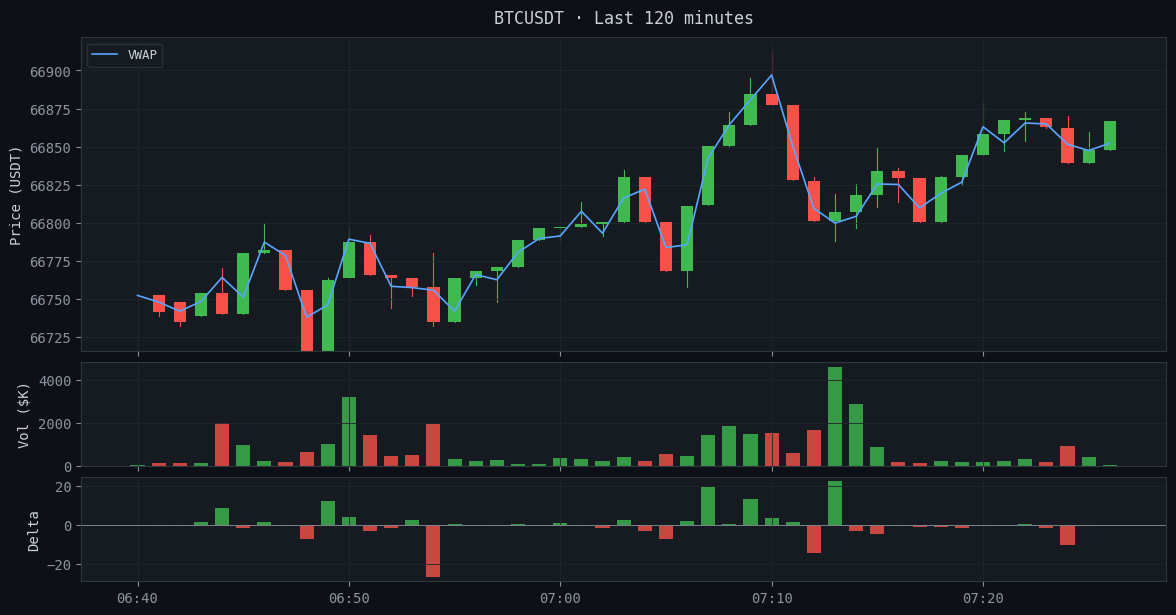

In [7]:
SYMBOL = 'BTCUSDT'
LIMIT  = 120   # last N candles

df = con.sql(f"""
    select candle_time, open, high, low, close, volume_usd, vwap, volume_delta
    from {SILVER}.stg_ohlcv_1min
    where symbol = '{SYMBOL}'
    order by candle_time desc
    limit {LIMIT}
""").df().sort_values('candle_time')

df['candle_time'] = pd.to_datetime(df['candle_time'])
df['is_bull']     = df['close'] >= df['open']

fig = plt.figure(figsize=(14, 8))
gs  = GridSpec(3, 1, figure=fig, height_ratios=[3, 1, 1], hspace=0.06)

ax1 = fig.add_subplot(gs[0])   # price
ax2 = fig.add_subplot(gs[1], sharex=ax1)   # volume
ax3 = fig.add_subplot(gs[2], sharex=ax1)   # volume delta

# ── candlesticks ──
for _, row in df.iterrows():
    color = COLORS['buy'] if row['is_bull'] else COLORS['sell']
    t     = mdates.date2num(row['candle_time'])
    w     = 0.0004
    ax1.bar(t, abs(row['close'] - row['open']), w,
            bottom=min(row['open'], row['close']), color=color, zorder=2)
    ax1.plot([t, t], [row['low'], row['high']], color=color, lw=0.8, zorder=1)

# ── VWAP line ──
ax1.plot(df['candle_time'], df['vwap'], color=COLORS['vwap'],
         lw=1.2, label='VWAP', zorder=3)

ax1.set_ylabel('Price (USDT)')
ax1.set_title(f'{SYMBOL} · Last {LIMIT} minutes', fontsize=12, color='#c9d1d9', pad=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax1.get_xticklabels(), visible=False)

# ── volume bars ──
bar_colors = [COLORS['buy'] if b else COLORS['sell'] for b in df['is_bull']]
ax2.bar(df['candle_time'], df['volume_usd'] / 1e3, width=pd.Timedelta('40s'),
        color=bar_colors, alpha=0.8)
ax2.set_ylabel('Vol ($K)')
plt.setp(ax2.get_xticklabels(), visible=False)

# ── volume delta ──
delta_colors = [COLORS['buy'] if d >= 0 else COLORS['sell'] for d in df['volume_delta']]
ax3.bar(df['candle_time'], df['volume_delta'], width=pd.Timedelta('40s'),
        color=delta_colors, alpha=0.8)
ax3.axhline(0, color='#8b949e', lw=0.6)
ax3.set_ylabel('Delta')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig.autofmt_xdate(rotation=0, ha='center')
plt.savefig('charts/ohlcv_btc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bollinger Bands + %B

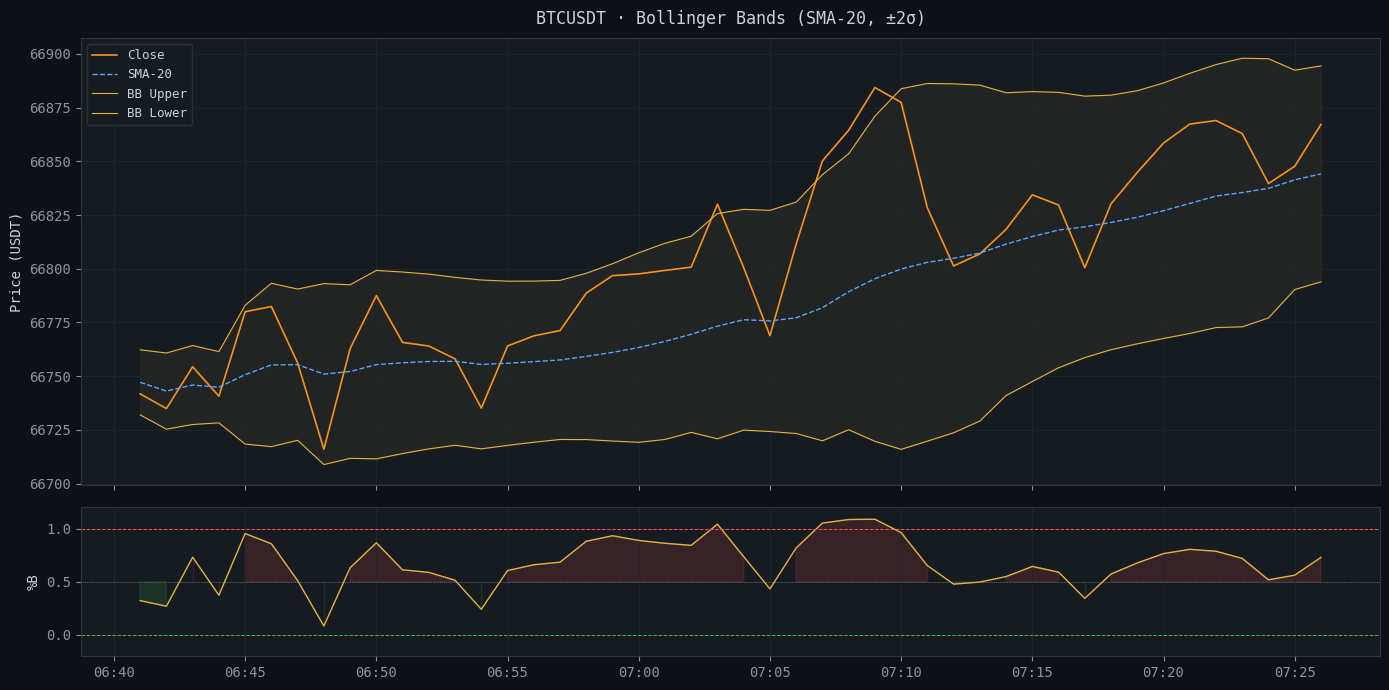

In [8]:
df_vol = con.sql(f"""
    select candle_time, close, sma_20, bb_upper, bb_lower,
           pct_b, realized_vol_pct, bb_bandwidth
    from {GOLD}.mart_volatility
    where symbol = '{SYMBOL}'
    order by candle_time desc
    limit {LIMIT}
""").df().sort_values('candle_time')

df_vol['candle_time'] = pd.to_datetime(df_vol['candle_time'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                               sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# ── price + bands ──
ax1.plot(df_vol['candle_time'], df_vol['close'],
         color=COLORS['btc'], lw=1.2, label='Close')
ax1.plot(df_vol['candle_time'], df_vol['sma_20'],
         color=COLORS['sma'], lw=1.0, ls='--', label='SMA-20')
ax1.plot(df_vol['candle_time'], df_vol['bb_upper'],
         color=COLORS['bb'], lw=0.8, label='BB Upper')
ax1.plot(df_vol['candle_time'], df_vol['bb_lower'],
         color=COLORS['bb'], lw=0.8, label='BB Lower')
ax1.fill_between(df_vol['candle_time'],
                 df_vol['bb_upper'], df_vol['bb_lower'],
                 alpha=0.06, color=COLORS['bb'])
ax1.set_ylabel('Price (USDT)')
ax1.set_title(f'{SYMBOL} · Bollinger Bands (SMA-20, ±2σ)', fontsize=12, pad=10)
ax1.legend(loc='upper left', fontsize=9)

# ── %B indicator ──
ax2.plot(df_vol['candle_time'], df_vol['pct_b'],
         color=COLORS['bb'], lw=1.0)
ax2.axhline(1.0, color=COLORS['sell'],  lw=0.7, ls='--')
ax2.axhline(0.5, color='#8b949e',       lw=0.5, ls=':')
ax2.axhline(0.0, color=COLORS['buy'],   lw=0.7, ls='--')
ax2.fill_between(df_vol['candle_time'], df_vol['pct_b'], 0.5,
                 where=df_vol['pct_b'] >= 0.5,
                 alpha=0.15, color=COLORS['sell'])
ax2.fill_between(df_vol['candle_time'], df_vol['pct_b'], 0.5,
                 where=df_vol['pct_b'] < 0.5,
                 alpha=0.15, color=COLORS['buy'])
ax2.set_ylabel('%B')
ax2.set_ylim(-0.2, 1.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('charts/bollinger_btc.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. VWAP · Price vs fair value

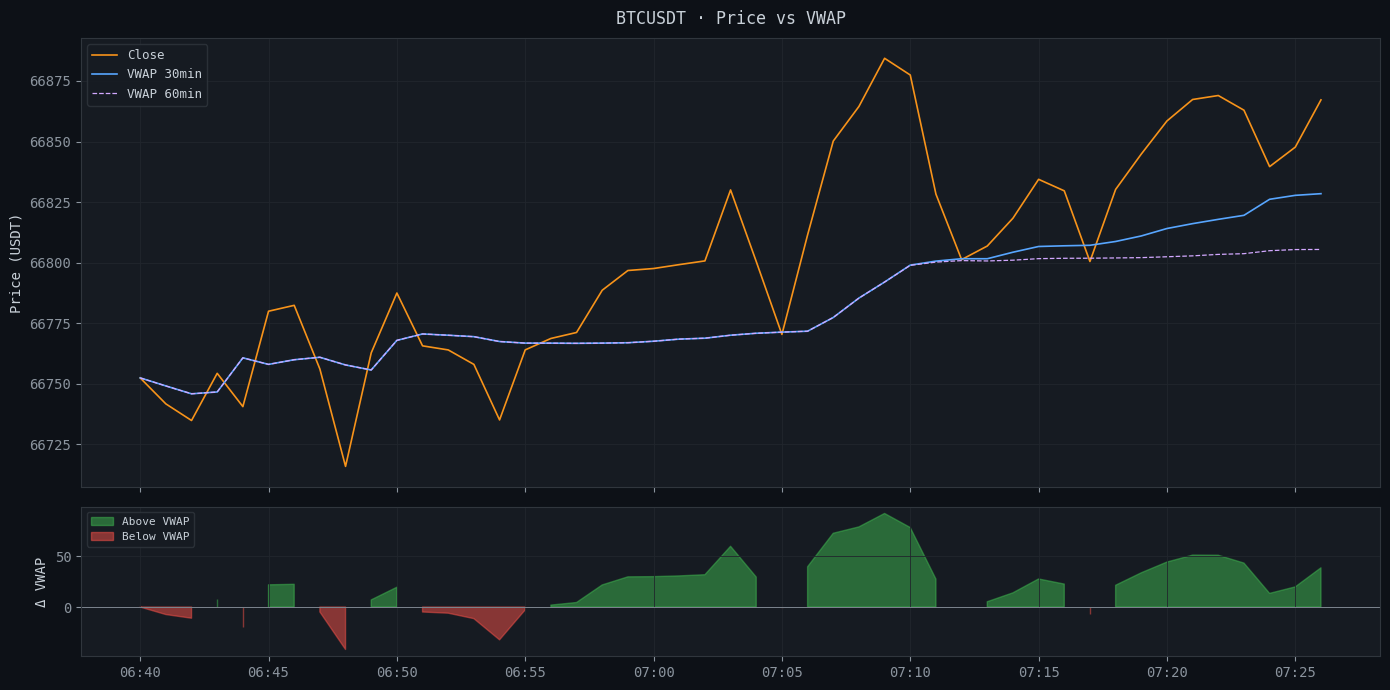

In [9]:
df_vwap = con.sql(f"""
    select candle_time, close, vwap_30min, vwap_60min,
           price_vs_vwap, hourly_vwap
    from {GOLD}.mart_vwap
    where symbol = '{SYMBOL}'
    order by candle_time desc
    limit {LIMIT}
""").df().sort_values('candle_time')

df_vwap['candle_time'] = pd.to_datetime(df_vwap['candle_time'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                               sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df_vwap['candle_time'], df_vwap['close'],
         color=COLORS['btc'], lw=1.2, label='Close')
ax1.plot(df_vwap['candle_time'], df_vwap['vwap_30min'],
         color=COLORS['vwap'], lw=1.2, label='VWAP 30min')
ax1.plot(df_vwap['candle_time'], df_vwap['vwap_60min'],
         color='#d2a8ff', lw=0.9, ls='--', label='VWAP 60min')

ax1.set_ylabel('Price (USDT)')
ax1.set_title(f'{SYMBOL} · Price vs VWAP', fontsize=12, pad=10)
ax1.legend(loc='upper left', fontsize=9)

# ── price deviation from VWAP ──
ax2.fill_between(df_vwap['candle_time'], df_vwap['price_vs_vwap'], 0,
                 where=df_vwap['price_vs_vwap'] >= 0,
                 alpha=0.5, color=COLORS['buy'], label='Above VWAP')
ax2.fill_between(df_vwap['candle_time'], df_vwap['price_vs_vwap'], 0,
                 where=df_vwap['price_vs_vwap'] < 0,
                 alpha=0.5, color=COLORS['sell'], label='Below VWAP')
ax2.axhline(0, color='#8b949e', lw=0.6)
ax2.set_ylabel('Δ VWAP')
ax2.legend(loc='upper left', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('charts/vwap_btc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Whale trades · Large market participants

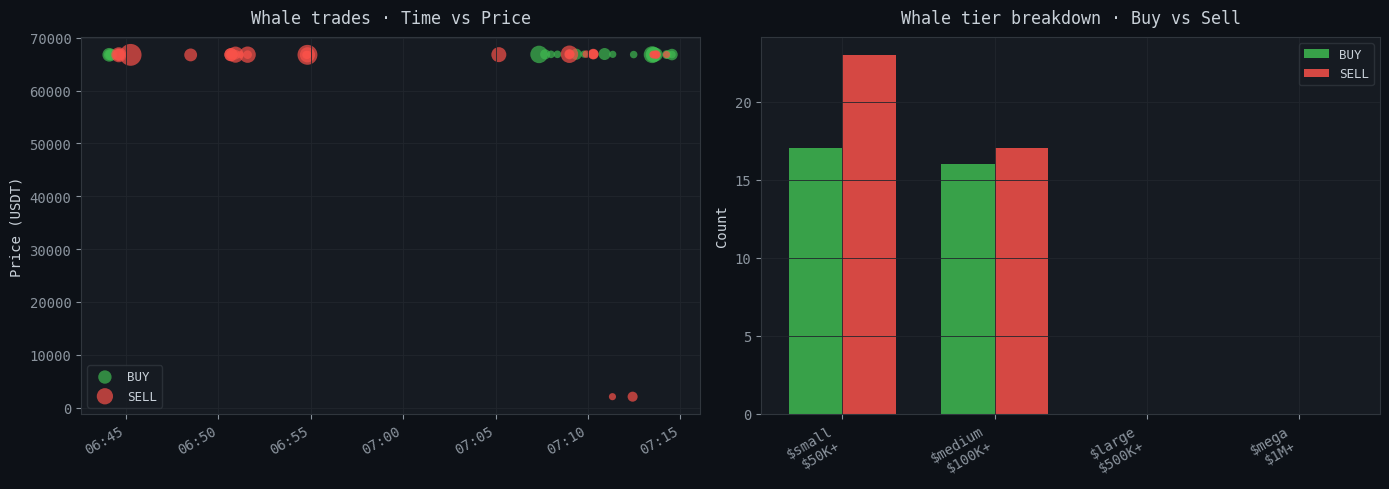


Top 10 largest trades:


,traded_at,symbol,price,volume_usd,side,whale_tier,pct_of_hour_volume
65,2026-04-03 09:45:14.949000+03:00,BTCUSDT,66750.00,496024.590000,SELL,medium,3.4933
48,2026-04-03 09:54:49.131000+03:00,BTCUSDT,66758.00,410671.183120,SELL,medium,2.8922
43,2026-04-03 10:07:21+03:00,BTCUSDT,66834.49,317651.632417,BUY,medium,1.4027
38,2026-04-03 10:08:59.558000+03:00,BTCUSDT,66871.00,315554.887060,SELL,medium,1.3934
23,2026-04-03 10:13:28.313000+03:00,BTCUSDT,66788.00,297253.351600,BUY,medium,1.3126
53,2026-04-03 09:51:34.814000+03:00,BTCUSDT,66789.00,277335.979380,SELL,medium,1.9532
56,2026-04-03 09:50:55.517000+03:00,BTCUSDT,66792.00,270636.508560,SELL,medium,1.9060
21,2026-04-03 10:13:32.003000+03:00,BTCUSDT,66800.00,244276.912000,BUY,medium,1.0787
46,2026-04-03 09:54:49.132000+03:00,BTCUSDT,66758.00,237658.480000,SELL,medium,1.6737
68,2026-04-03 09:44:36.581000+03:00,BTCUSDT,66770.00,234788.692600,SELL,medium,1.6535


In [11]:
df_whale = con.sql(f"""
    select traded_at, symbol, price, volume_usd, side, whale_tier,
           pct_of_hour_volume, hour_net_pressure
    from {GOLD}.mart_whale_trades
    order by traded_at desc
    limit 200
""").df()

df_whale['traded_at'] = pd.to_datetime(df_whale['traded_at'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── scatter: time vs price, sized by volume ──
ax = axes[0]
for side, color in [('BUY', COLORS['buy']), ('SELL', COLORS['sell'])]:
    mask = df_whale['side'] == side
    ax.scatter(
        df_whale.loc[mask, 'traded_at'],
        df_whale.loc[mask, 'price'],
        s=df_whale.loc[mask, 'volume_usd'] / 2000,
        c=color, alpha=0.7, label=side, edgecolors='none'
    )
ax.set_title('Whale trades · Time vs Price', pad=10)
ax.set_ylabel('Price (USDT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend(fontsize=9)
fig.autofmt_xdate(rotation=30, ha='right')

# ── bar: whale tier breakdown ──
ax2 = axes[1]
tier_order  = ['small', 'medium', 'large', 'mega']
tier_counts = df_whale.groupby(['whale_tier', 'side']).size().unstack(fill_value=0)
tier_counts = tier_counts.reindex(tier_order, fill_value=0)

x    = range(len(tier_counts))
w    = 0.35
buys  = tier_counts.get('BUY',  pd.Series([0]*4))
sells = tier_counts.get('SELL', pd.Series([0]*4))

ax2.bar([i - w/2 for i in x], buys,  w, color=COLORS['buy'],  label='BUY',  alpha=0.85)
ax2.bar([i + w/2 for i in x], sells, w, color=COLORS['sell'], label='SELL', alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels([f'${t}\n${["50K","100K","500K","1M"][i]}+'
                     for i, t in enumerate(tier_order)])
ax2.set_title('Whale tier breakdown · Buy vs Sell', pad=10)
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/whale_trades.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 largest trades:')
df_whale.nlargest(10, 'volume_usd')[[
    'traded_at', 'symbol', 'price', 'volume_usd', 'side', 'whale_tier', 'pct_of_hour_volume'
]]

## 6. Multi-symbol comparison · Volatility

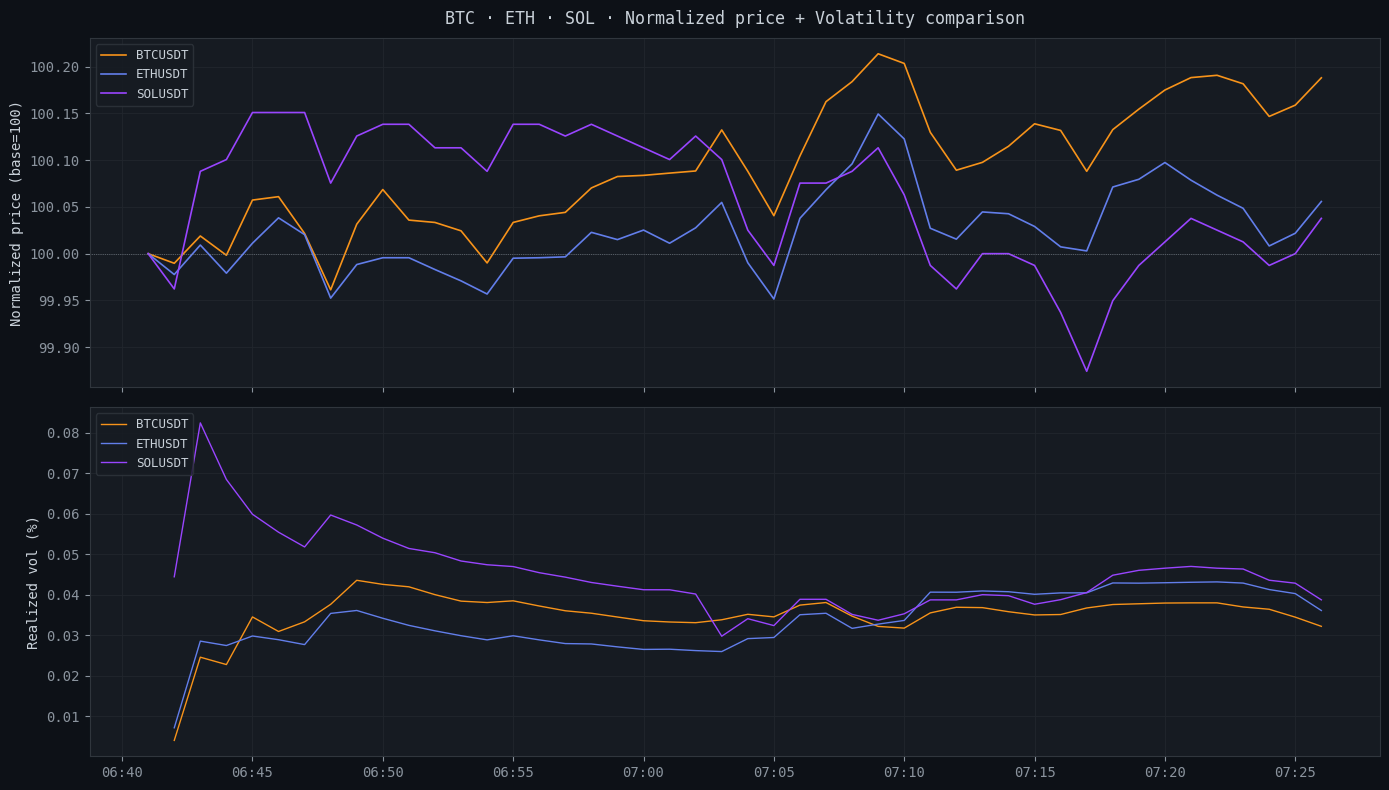

In [12]:
df_multi = con.sql(f"""
    select symbol, candle_time, realized_vol_pct, annualized_vol, close
    from {GOLD}.mart_volatility
    order by candle_time desc
    limit 360
""").df().sort_values(['symbol', 'candle_time'])

df_multi['candle_time'] = pd.to_datetime(df_multi['candle_time'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── normalized price (base = 100) ──
ax1 = axes[0]
for symbol, grp in df_multi.groupby('symbol'):
    base  = grp['close'].iloc[0]
    color = SYMBOL_COLORS.get(symbol, '#ffffff')
    ax1.plot(grp['candle_time'], grp['close'] / base * 100,
             color=color, lw=1.2, label=symbol)
ax1.axhline(100, color='#8b949e', lw=0.5, ls=':')
ax1.set_ylabel('Normalized price (base=100)')
ax1.set_title('BTC · ETH · SOL · Normalized price + Volatility comparison', fontsize=12, pad=10)
ax1.legend(loc='upper left', fontsize=9)

# ── realized volatility ──
ax2 = axes[1]
for symbol, grp in df_multi.groupby('symbol'):
    color = SYMBOL_COLORS.get(symbol, '#ffffff')
    ax2.plot(grp['candle_time'], grp['realized_vol_pct'],
             color=color, lw=1.0, label=symbol)
ax2.set_ylabel('Realized vol (%)')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('charts/multi_symbol_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Buy / Sell pressure heatmap

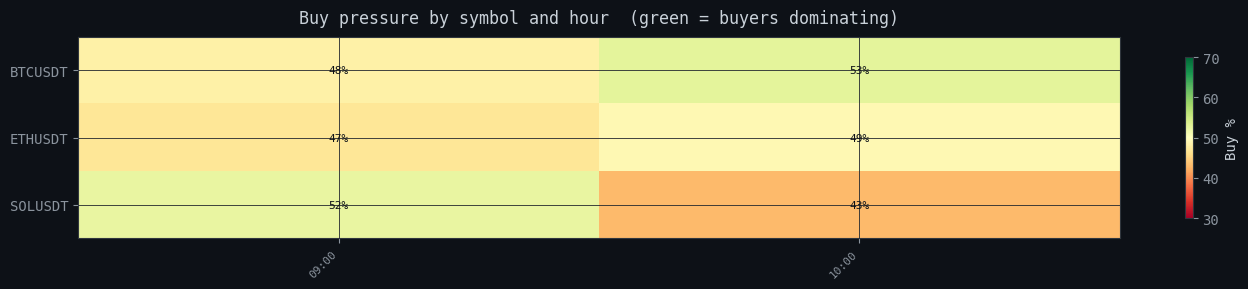

In [13]:
import numpy as np

df_pressure = con.sql(f"""
    select
        symbol,
        date_trunc('hour', traded_at)           as hour,
        round(sum(volume_usd) filter (where side = 'BUY')
            / nullif(sum(volume_usd), 0) * 100, 1) as buy_pct
    from {SILVER}.stg_trades
    group by 1, 2
    order by symbol, hour
""").df()

df_pressure['hour'] = pd.to_datetime(df_pressure['hour'])
pivot = df_pressure.pivot(index='symbol', columns='hour', values='buy_pct')

fig, ax = plt.subplots(figsize=(14, 3))

im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
               vmin=30, vmax=70, interpolation='nearest')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [h.strftime('%H:%M') for h in pivot.columns],
    rotation=45, ha='right', fontsize=8
)

# annotate cells with value
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='#0d1117' if 40 < val < 60 else '#c9d1d9')

plt.colorbar(im, ax=ax, label='Buy %', shrink=0.8)
ax.set_title('Buy pressure by symbol and hour  (green = buyers dominating)', pad=10)

plt.tight_layout()
plt.savefig('charts/buy_pressure_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
con.close()
print('Connection closed.')

Connection closed.
